In [2]:
pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 9.2 MB/s eta 0:00:00MB/s eta 0:00:01:01m
Note: you may need to restart the kernel to use updated packages.


/Users/jalprathik/miniforge3/envs/dsc80/lib/python3.12/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **kwargs)
/Users/jalprathik/miniforge3/envs/dsc80/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/jalprathik/miniforge3/envs/dsc80/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


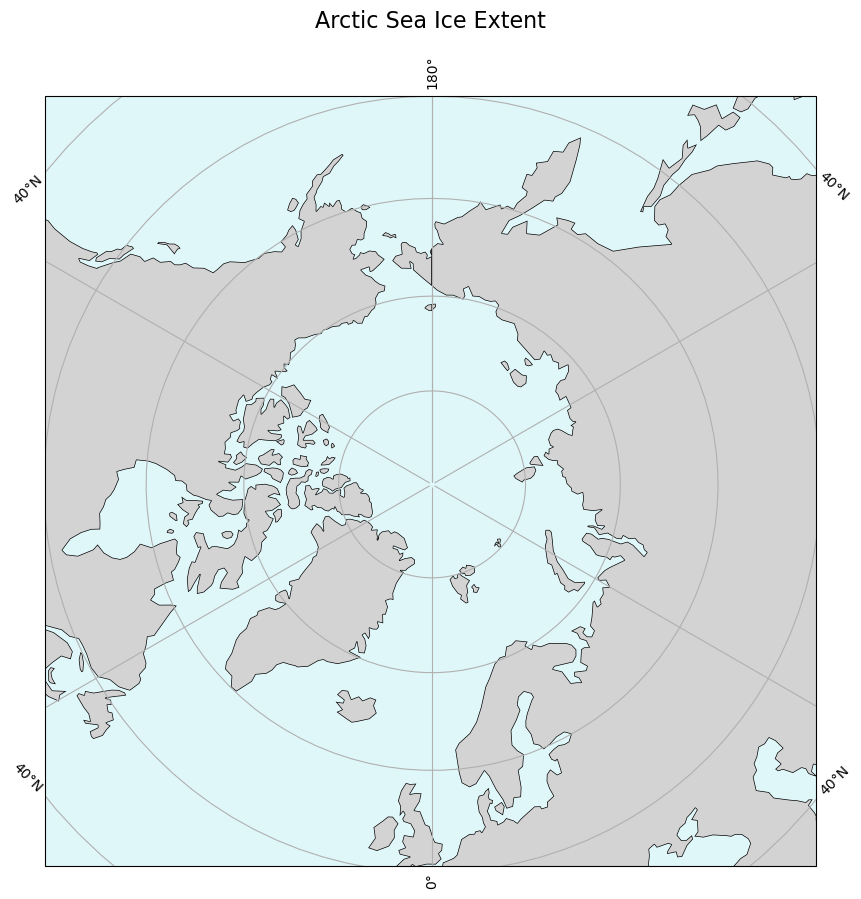

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Load your GeoJSON data
# We must explicitly tell GeoPandas what coordinate system the original file uses
file_path = "extent_N_202509_polygon_v4.0.json"
ice_extent = gpd.read_file(file_path)
ice_extent.to_crs(epsg=3413, inplace=True)

# 2. Set up the map projection (Looking straight down at the North Pole)
fig = plt.figure(figsize=(10, 10))

ax = plt.axes(projection=ccrs.NorthPolarStereo())

# 3. Restrict the view to the Northern Hemisphere (down to 50 degrees latitude)
ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())

# 4. Add Earth's visual features for context
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black')
ax.add_feature(cfeature.OCEAN, facecolor='#e0f7fa')
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# 5. Plot the ice data! 
# Cartopy and GeoPandas will automatically translate the EPSG:3413 meters 
# into the correct physical locations on the 3D globe projection.
ice_extent.plot(ax=ax, transform=ccrs.epsg(3413), color='white', edgecolor='#0055ff', alpha=0.85, linewidth=2)

plt.title("Arctic Sea Ice Extent", fontsize=16, pad=20)
plt.show()


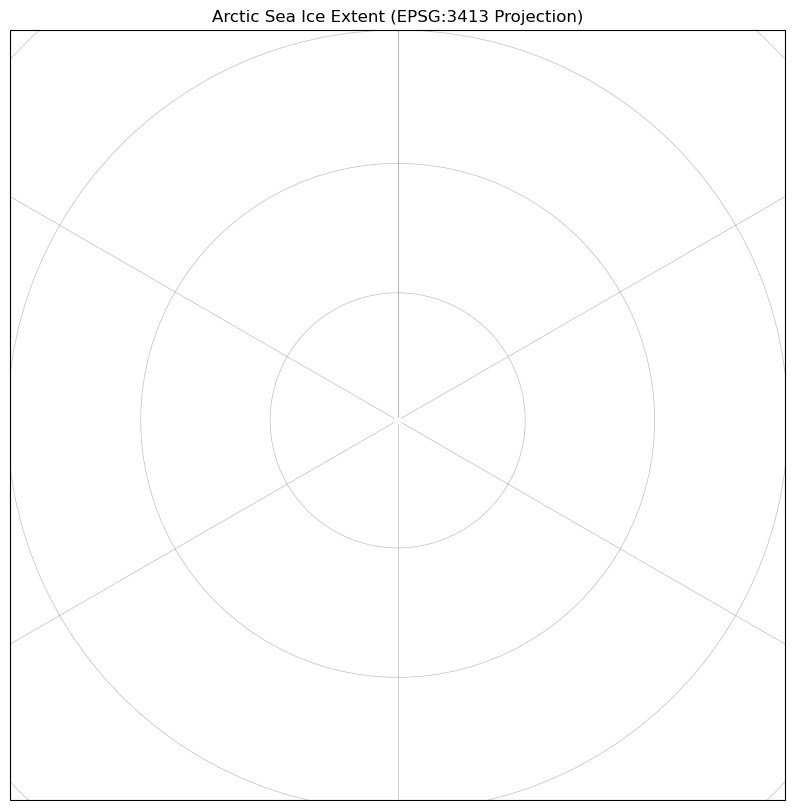

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# 1. Load the GeoJSON (currently in EPSG:4326)
file_path = "extent_N_202509_polygon_v4.0.json"
ice_extent = gpd.read_file(file_path)
ice_extent["geometry"] = ice_extent.buffer(0)

# 2. Reproject to Arctic Polar Stereographic (EPSG:3413)
ice_extent = ice_extent.to_crs(epsg=3413)

# 3. Plot
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

ax.add_geometries(
    ice_extent.geometry,
    crs=ccrs.epsg(3413),
    facecolor='lightblue',
    edgecolor='black',
    linewidth=0.8
)

# 4. Set map extent (lat/lon bounds, but PlateCarree for interpretation)
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

# 5. Add gridlines for reference
ax.gridlines(draw_labels=False, color='gray', linewidth=0.5, alpha=0.5)

plt.title("Arctic Sea Ice Extent (EPSG:3413 Projection)")
plt.show()



In [6]:
ice_extent.is_empty.sum()


np.int64(0)

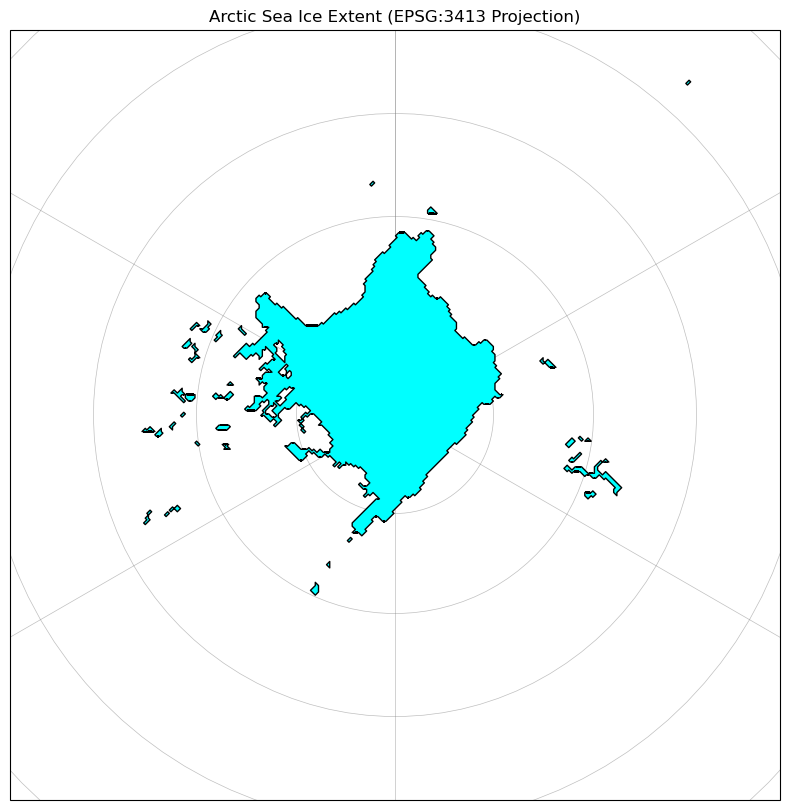

In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

file_path = "extent_N_202509_polygon_v4.0.json"
ice_extent = gpd.read_file(file_path)

# Your data is ALREADY in EPSG:3413
ice_extent = ice_extent.set_crs(epsg=3413, allow_override=True)

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

ax.add_geometries(
    ice_extent.geometry,
    crs=ccrs.epsg(3413),
    facecolor='cyan',
    edgecolor='black',
    linewidth=1.0,
    zorder=10
)

ax.set_extent([-3e6, 3e6, -3e6, 3e6], crs=ccrs.epsg(3413))
ax.gridlines(draw_labels=False, color='gray', linewidth=0.5, alpha=0.5)

plt.title("Arctic Sea Ice Extent (EPSG:3413 Projection)")
plt.show()


/Users/jalprathik/miniforge3/envs/dsc80/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/jalprathik/miniforge3/envs/dsc80/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


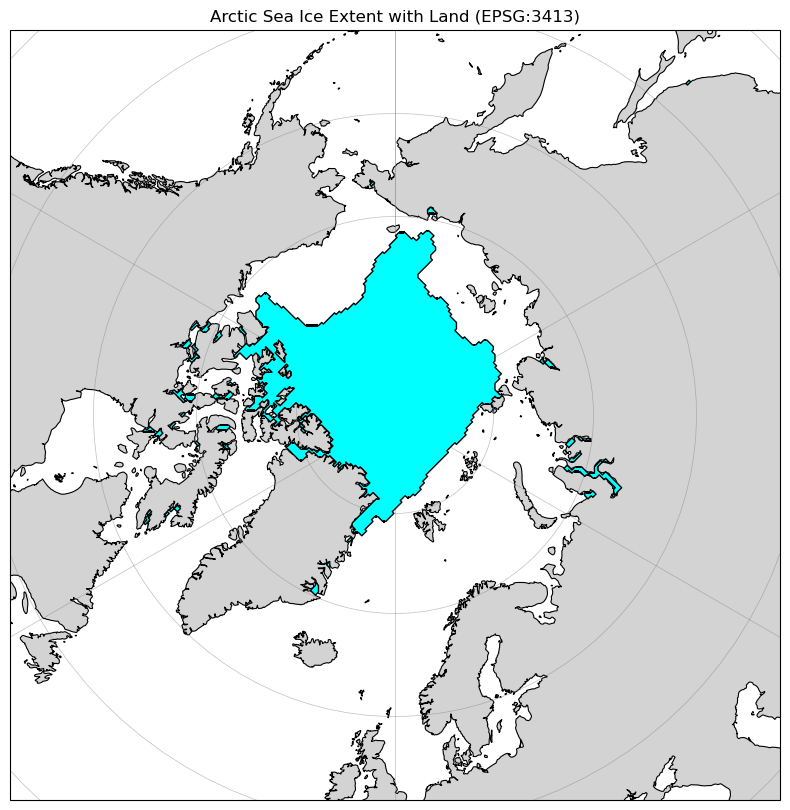

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

file_path = "extent_N_202509_polygon_v4.0.json"
ice_extent = gpd.read_file(file_path)

# Your data is already in EPSG:3413
ice_extent = ice_extent.set_crs(epsg=3413, allow_override=True)

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# Add land (Cartopy’s built‑in dataset)
land = cfeature.NaturalEarthFeature(
    'physical', 'land', '50m',
    facecolor='lightgray'
)
ax.add_feature(land, zorder=1)

# Add coastlines
ax.coastlines(resolution='50m', linewidth=0.8, zorder=2)

# Add your ice polygons
ax.add_geometries(
    ice_extent.geometry,
    crs=ccrs.epsg(3413),
    facecolor='cyan',
    edgecolor='black',
    linewidth=1.0,
    zorder=10
)

# Set extent in EPSG:3413 meters
ax.set_extent([-3e6, 3e6, -3e6, 3e6], crs=ccrs.epsg(3413))

ax.gridlines(draw_labels=False, color='gray', linewidth=0.5, alpha=0.5)
plt.title("Arctic Sea Ice Extent with Land (EPSG:3413)")
plt.show()


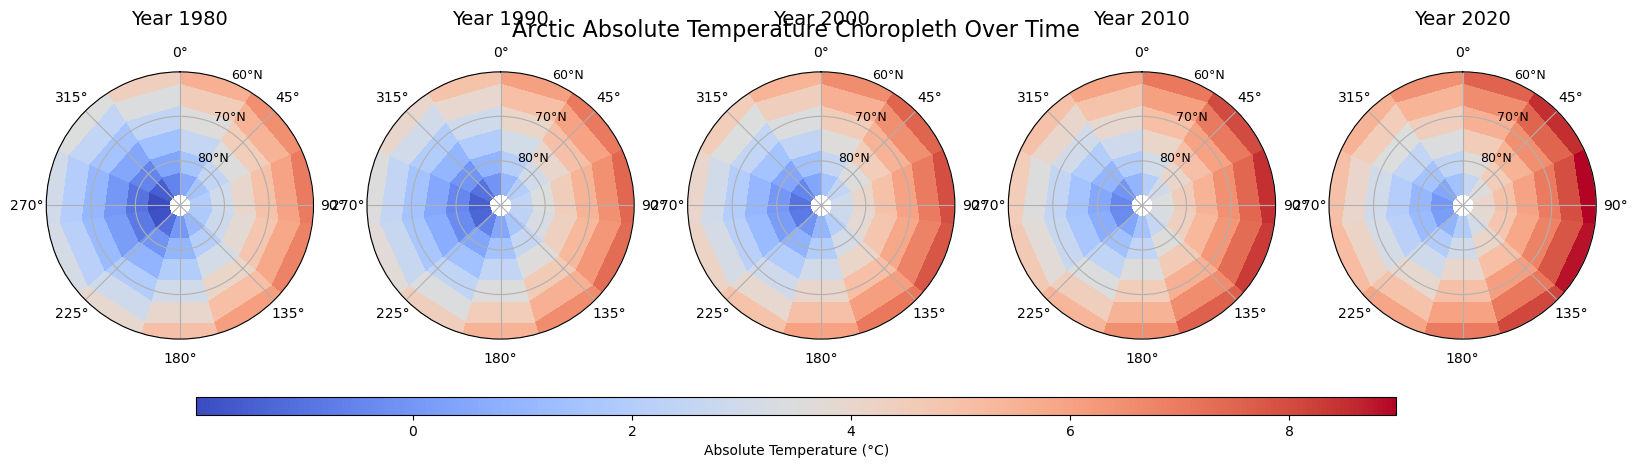

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your JSON data
# (Replacing this with your actual file path or JSON string)
df = pd.read_json("downsampled_arctic_data_1980_onwards.json")

# Dummy data replication matching your schema for illustration:
data = []
for y in [1980, 1990, 2000, 2010, 2020]:
    for lat in np.linspace(60, 85, 6):
        for lon in np.linspace(-180, 180, 12):
            temp = 5 + (y - 1980) * 0.05 - (lat - 60) * 0.2 + np.sin(np.radians(lon)) * 2
            data.append({"year": y, "lat": lat, "lon": lon, "region": "Arctic / High North", "temp_absolute": temp})
df = pd.DataFrame(data)

# 2. Sort and extract time steps
df = df.sort_values(by=['year', 'lat', 'lon'])
years = sorted(df['year'].unique())
num_years = len(years)

# 3. Initialize polar subplots for each year
fig, axes = plt.subplots(1, num_years, subplot_kw={'projection': 'polar'}, figsize=(4 * num_years, 4.5))
if num_years == 1:
    axes = [axes]

# Define color limits across the entire dataset for consistency
vmin, vmax = df['temp_absolute'].min(), df['temp_absolute'].max()

for i, y in enumerate(years):
    df_y = df[df['year'] == y]
    
    # Pivot to create a clean matrix for pcolormesh
    pivot_df = df_y.pivot(index='lat', columns='lon', values='temp_absolute')
    pivot_df = pivot_df.sort_index(ascending=False)  # High lat to low lat
    pivot_df = pivot_df.reindex(sorted(pivot_df.columns), axis=1)
    
    # Polar conversion: 
    # Center of the plot (r=0) is the North Pole (90°N), so radius r = 90 - latitude
    r_coords = 90 - pivot_df.index.values
    theta_coords = np.radians(pivot_df.columns.values)
    
    Theta, R = np.meshgrid(theta_coords, r_coords)
    Values = pivot_df.values
    
    ax = axes[i]
    # Plot using pcolormesh to fill grid squares like a traditional choropleth
    mesh = ax.pcolormesh(Theta, R, Values, cmap='coolwarm', shading='auto', vmin=vmin, vmax=vmax)
    
    # Orient the map: North Pole in center, 0° longitude pointing straight up
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)  # Clockwise longitude direction
    
    # Limit boundary to the Arctic Circle (e.g., down to 60°N -> max radius = 30)
    max_r = 90 - df['lat'].min()
    ax.set_ylim(0, max_r)
    
    # Format labels
    ticks = [10, 20, 30] if max_r >= 30 else [5, 15, 25]
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"{90-t}°N" for t in ticks], color='black', fontsize=9)
    ax.set_title(f"Year {y}", fontsize=14, pad=15)

# 4. Add a shared horizontal colorbar at the bottom
fig.subplots_adjust(bottom=0.25)
cbar_ax = fig.add_axes([0.2, 0.1, 0.6, 0.04])
fig.colorbar(mesh, cax=cbar_ax, orientation='horizontal', label='Absolute Temperature (°C)')

fig.suptitle("Arctic Absolute Temperature Choropleth Over Time", fontsize=16, y=0.98)

# Save and show the visualization
plt.savefig("arctic_time_choropleth.png", bbox_inches='tight', dpi=300)
plt.show()

In [12]:
import plotly.express as px
import pandas as pd

# Load your JSON data
# df = pd.read_json("your_data.json")

# Create the animated geographical scatter/density map
fig = px.scatter_geo(
    df,
    lat="lat",
    lon="lon",
    color="temp_absolute",
    animation_frame="year",
    projection="orthographic",
    title="Arctic Temperature Over Time (Animation)",
    color_continuous_scale="coolwarm",
    range_color=[df['temp_absolute'].min(), df['temp_absolute'].max()],
    labels={"temp_absolute": "Temp (°C)", "year": "Year"}
)

# Rotate the globe camera to look straight down at the North Pole
fig.update_geos(
    projection_rotation=dict(lat=90, lon=0, roll=0),
    showland=True, landcolor="whitesmoke",
    showocean=True, oceancolor="aliceblue",
    showcountries=True, countrycolor="darkgrey"
)

fig.update_layout(
    width=800,
    height=750,
    title_x=0.5
)

# Save as an interactive HTML webpage that you can open in any browser
fig.write_html("arctic_interactive_timeline.html")
fig.show()

ValueError: 
    Invalid value of type 'builtins.str' received for the 'colorscale' property of make_figure
        Received value: 'coolwarm'

    The 'colorscale' property is a colorscale and may be
    specified as:
      - A list of colors that will be spaced evenly to create the colorscale.
        Many predefined colorscale lists are included in the sequential, diverging,
        and cyclical modules in the plotly.colors package.
      - A list of 2-element lists where the first element is the
        normalized color level value (starting at 0 and ending at 1),
        and the second item is a valid color string.
        (e.g. [[0, 'green'], [0.5, 'red'], [1.0, 'rgb(0, 0, 255)']])
      - One of the following named colorscales:
            ['aggrnyl', 'agsunset', 'algae', 'amp', 'armyrose', 'balance',
             'blackbody', 'bluered', 'blues', 'blugrn', 'bluyl', 'brbg',
             'brwnyl', 'bugn', 'bupu', 'burg', 'burgyl', 'cividis', 'curl',
             'darkmint', 'deep'